# Exploration des données (EDA)
**Dataset** : Défaut de paiement carte de crédit (UCI, Taiwan 2005)  
Comprendre les données avant de construire les modèles

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Chargement et premier aperçu

In [10]:
# Charger le dataset
df = pd.read_csv('C:/Users/Anesti/Documents/M2/Machine Learning/data/credit_card_default.csv')

# Nettoyage colonnes
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Renommer la cible
for col in ['default.payment.next.month', 'default_payment_next_month', 'y']:
    if col in df.columns:
        df = df.rename(columns={col: 'default'})
        break

if 'id' in df.columns:
    df = df.drop(columns=['id'])

print(f'Shape : {df.shape}')
print(f'Valeurs manquantes : {df.isnull().sum().sum()}')
df.head(10)

Shape : (30000, 24)
Valeurs manquantes : 0


,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
5,50000.0,1,1,2,37,0,0,0,0,0,...,19394.0,19619.0,20024.0,2500.0,1815.0,657.0,1000.0,1000.0,800.0,0
6,500000.0,1,1,2,29,0,0,0,0,0,...,542653.0,483003.0,473944.0,55000.0,40000.0,38000.0,20239.0,13750.0,13770.0,0
7,100000.0,2,2,2,23,0,-1,-1,0,0,...,221.0,-159.0,567.0,380.0,601.0,0.0,581.0,1687.0,1542.0,0
8,140000.0,2,3,1,28,0,0,2,0,0,...,12211.0,11793.0,3719.0,3329.0,0.0,432.0,1000.0,1000.0,1000.0,0
9,20000.0,1,3,2,35,-2,-2,-2,-2,-1,...,0.0,13007.0,13912.0,0.0,0.0,0.0,13007.0,1122.0,0.0,0


In [11]:
# stats descriptives
df.describe().round(2)

,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,-0.27,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,1.13,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


## 2. La variable cible : défaut ou pas ?
Est-ce que le dataset est équilibré ?

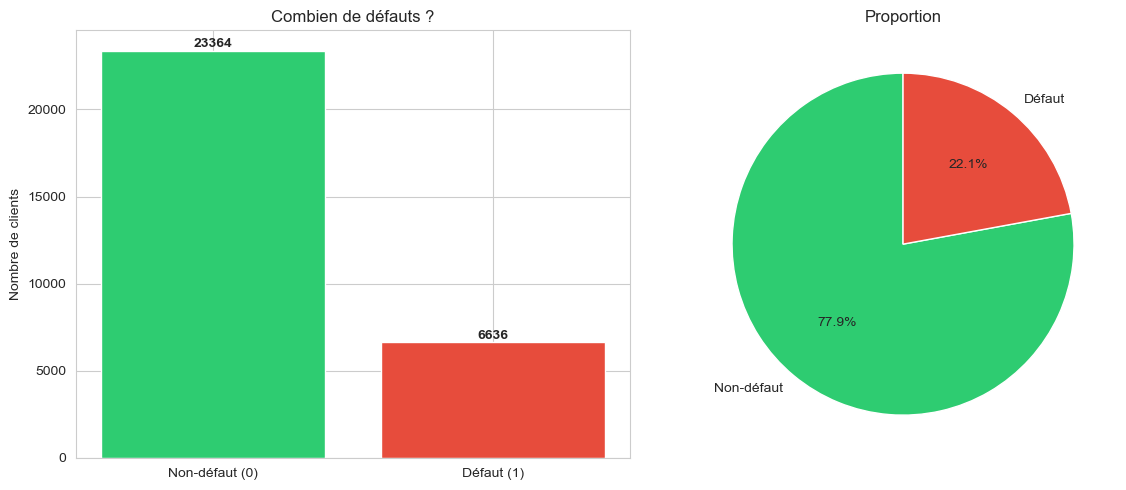

Ratio : 1 défaut pour 3.5 non-défauts
CONCLUSION : Le dataset est DÉSÉQUILIBRÉ (~22% de défauts).
Il faut utiliser, class_weight="balanced" pour les modèles classiques, Focal Loss pour le deep learning, AUC-ROC et F1-Score comme métriques


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
counts = df['default'].value_counts()
axes[0].bar(['Non-défaut (0)', 'Défaut (1)'], counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Combien de défauts ?')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# camembert
axes[1].pie(counts.values, labels=['Non-défaut', 'Défaut'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proportion')

plt.tight_layout()
plt.show()

print(f'Ratio : 1 défaut pour {counts[0]/counts[1]:.1f} non-défauts')
print('CONCLUSION : Le dataset est DÉSÉQUILIBRÉ (~22% de défauts).')
print('Il faut utiliser, class_weight="balanced" pour les modèles classiques, Focal Loss pour le deep learning, AUC-ROC et F1-Score comme métriques')

## 3. Variables catégorielles (SEX, EDUCATION, MARRIAGE)

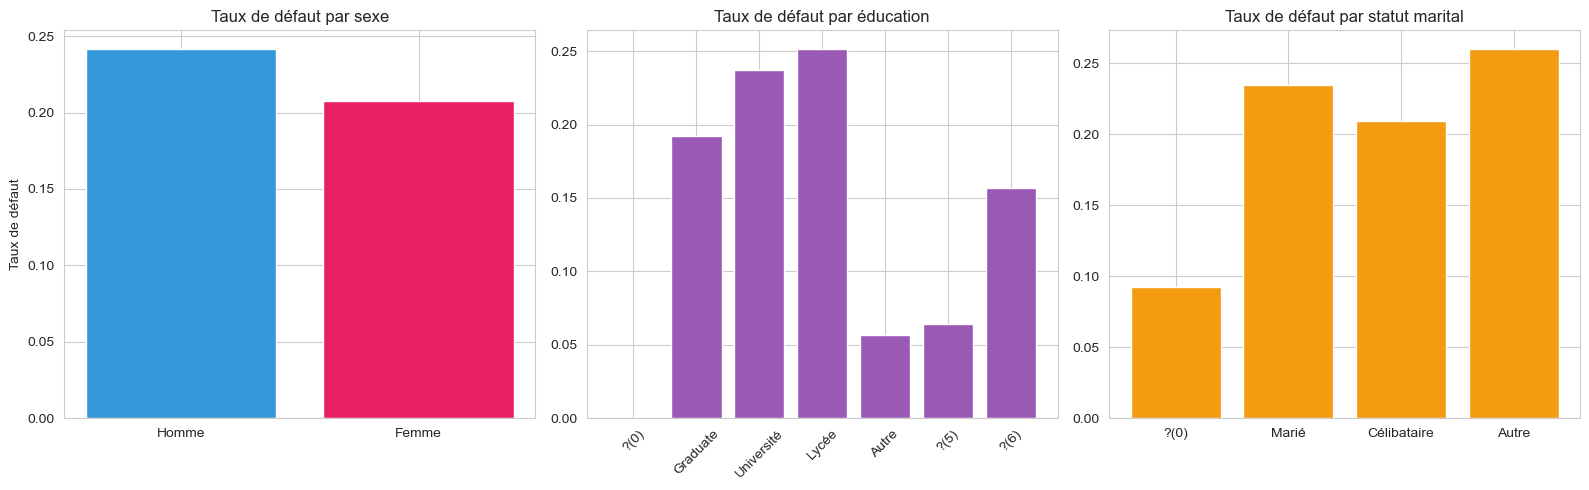

Valeurs dans EDUCATION : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Les 0, 5, 6 sont pas documentés, on les mettra dans Autre (4)
0=14, 5=280, 6=51
Valeurs dans MARRIAGE : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Le 0 est pas documenté, on le mettra dans Autre (3)
54


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# SEX
sex_labels = {1: 'Homme', 2: 'Femme'}
taux_sex = df.groupby('sex')['default'].mean()
axes[0].bar([sex_labels[x] for x in taux_sex.index], taux_sex.values, color=['#3498db', '#e91e63'])
axes[0].set_title('Taux de défaut par sexe')
axes[0].set_ylabel('Taux de défaut')

# EDUCATION
edu_labels = {1: 'Graduate', 2: 'Université', 3: 'Lycée', 4: 'Autre', 5: '?(5)', 6: '?(6)', 0: '?(0)'}
taux_edu = df.groupby('education')['default'].mean()
axes[1].bar([edu_labels.get(x, f'?({x})') for x in taux_edu.index], taux_edu.values, color='#9b59b6')
axes[1].set_title('Taux de défaut par éducation')
axes[1].tick_params(axis='x', rotation=45)

# MARRIAGE
mar_labels = {1: 'Marié', 2: 'Célibataire', 3: 'Autre', 0: '?(0)'}
taux_mar = df.groupby('marriage')['default'].mean()
axes[2].bar([mar_labels.get(x, f'?({x})') for x in taux_mar.index], taux_mar.values, color='#f39c12')
axes[2].set_title('Taux de défaut par statut marital')

plt.tight_layout()
plt.show()

# Verification valeurs
print('Valeurs dans EDUCATION :', sorted(df['education'].unique()))
print('Les 0, 5, 6 sont pas documentés, on les mettra dans Autre (4)')
print(f'0={df["education"].eq(0).sum()}, 5={df["education"].eq(5).sum()}, 6={df["education"].eq(6).sum()}')
print('Valeurs dans MARRIAGE :', sorted(df['marriage'].unique()))
print('Le 0 est pas documenté, on le mettra dans Autre (3)')
print(f'{df["marriage"].eq(0).sum()}')

## 4. Variables numériques

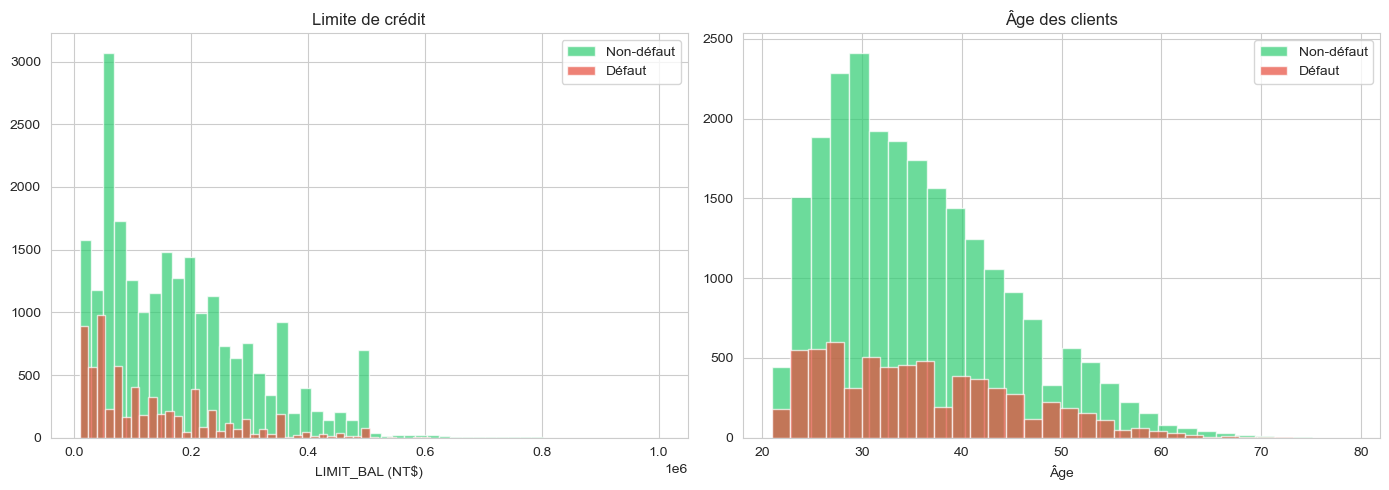

Les clients avec une faible limite de crédit font plus souvent défaut.
L'âge a un impact plus faible.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LIMIT_BAL par défaut/non-défaut
df[df['default']==0]['limit_bal'].hist(ax=axes[0], bins=50, alpha=0.7, label='Non-défaut', color='#2ecc71')
df[df['default']==1]['limit_bal'].hist(ax=axes[0], bins=50, alpha=0.7, label='Défaut', color='#e74c3c')
axes[0].set_title('Limite de crédit')
axes[0].set_xlabel('LIMIT_BAL (NT$)')
axes[0].legend()

# AGE par défaut/non-défaut
df[df['default']==0]['age'].hist(ax=axes[1], bins=30, alpha=0.7, label='Non-défaut', color='#2ecc71')
df[df['default']==1]['age'].hist(ax=axes[1], bins=30, alpha=0.7, label='Défaut', color='#e74c3c')
axes[1].set_title('Âge des clients')
axes[1].set_xlabel('Âge')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Les clients avec une faible limite de crédit font plus souvent défaut.')
print('L\'âge a un impact plus faible.')

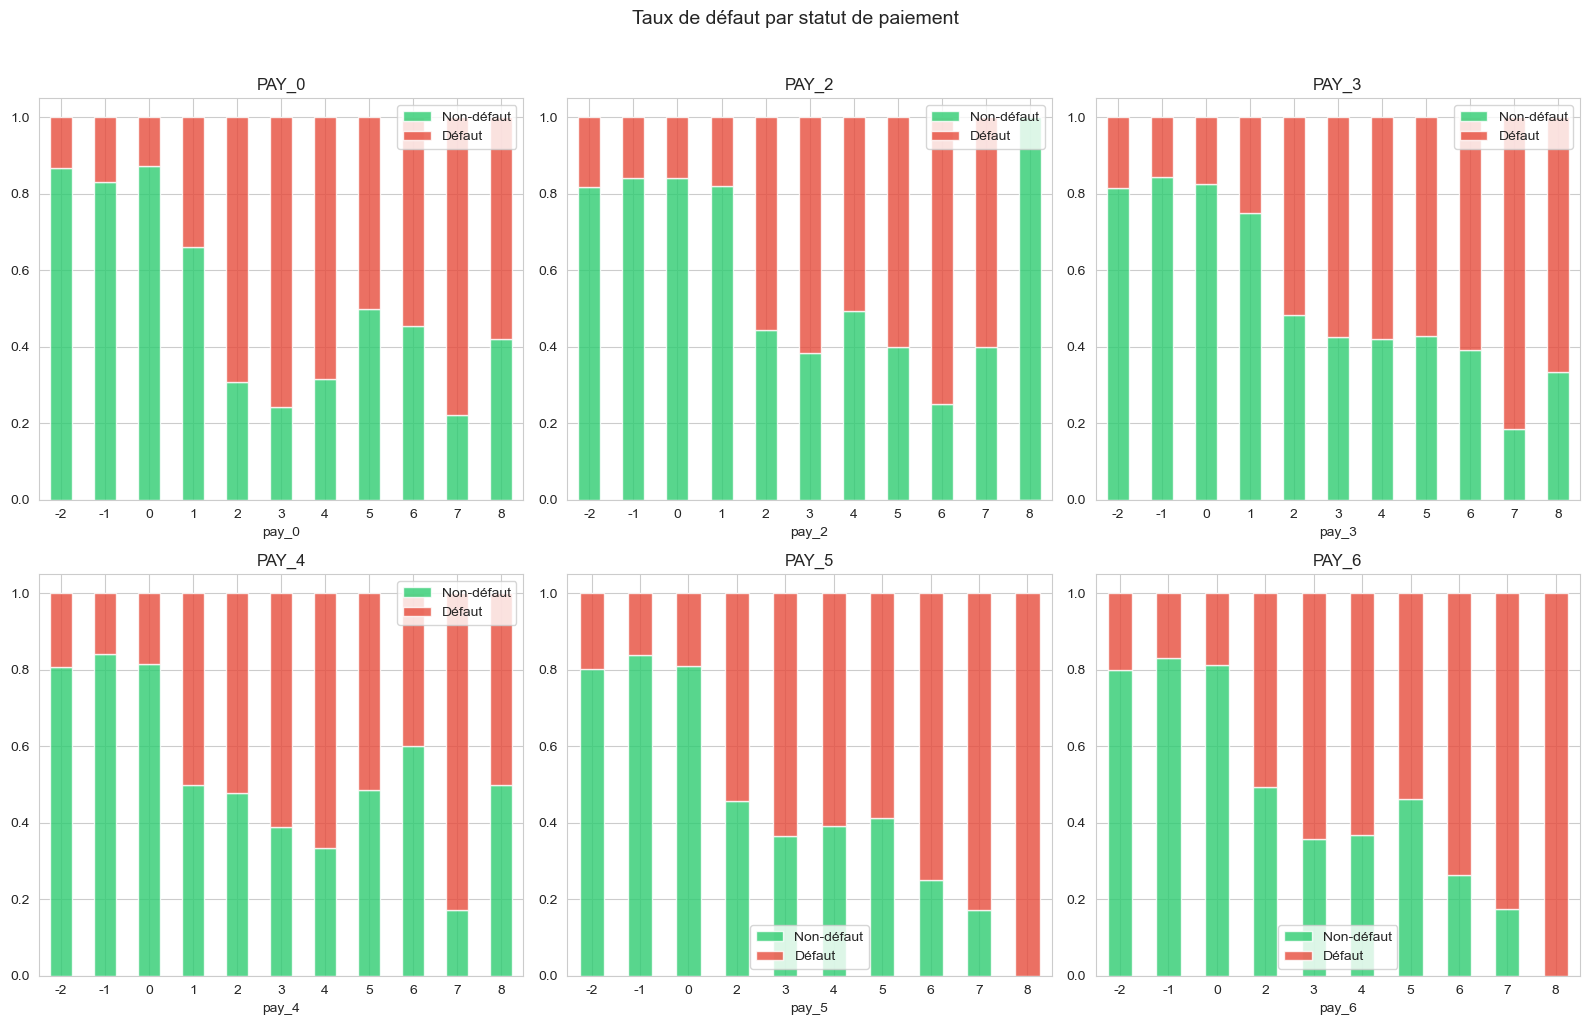

Statuts : -2=pas de conso, -1=payé, 0=paiement min, 1=retard 1 mois, ...

OBSERVATION CLÉ : Le retard de paiement est le MEILLEUR prédicteur.
Quelqu'un en retard de 2+ mois a > 60% de chances de faire défaut.


In [15]:
# Statuts de paiement
pay_cols = [c for c in df.columns if c.startswith('pay_') and 'amt' not in c]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(pay_cols[:6]):
    ct = pd.crosstab(df[col], df['default'], normalize='index')
    ct.plot(kind='bar', ax=axes[i], stacked=True, color=['#2ecc71', '#e74c3c'], alpha=0.8)
    axes[i].set_title(col.upper())
    axes[i].legend(['Non-défaut', 'Défaut'])
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Taux de défaut par statut de paiement', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Statuts : -2=pas de conso, -1=payé, 0=paiement min, 1=retard 1 mois, ...')
print()
print('OBSERVATION CLÉ : Le retard de paiement est le MEILLEUR prédicteur.')
print('Quelqu\'un en retard de 2+ mois a > 60% de chances de faire défaut.')

## 5. Corrélations

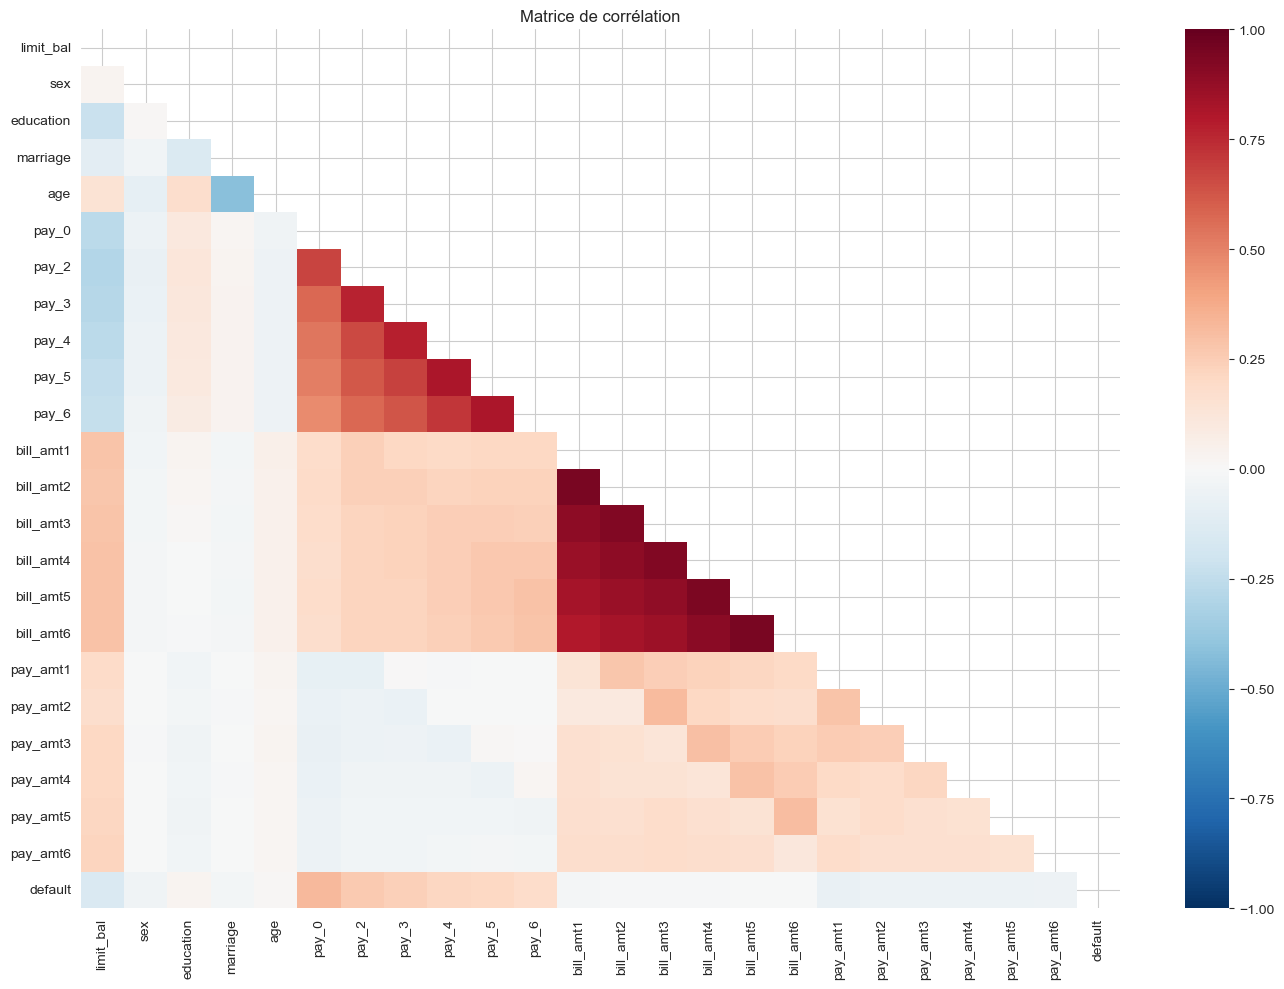

Corrélations avec DEFAULT (triées par importance) :
pay_0        0.325
pay_2        0.264
pay_3        0.235
pay_4        0.217
pay_5        0.204
pay_6        0.187
limit_bal   -0.154
pay_amt1    -0.073
pay_amt2    -0.059
pay_amt4    -0.057
Name: default, dtype: float64

OBSERVATIONS :
PAY_0 a la plus forte corrélation avec le défaut
BILL_AMT1-6 sont très corrélés entre eux (= multicolinéarité)
Les montants de factures ont une faible corrélation avec le défaut


In [16]:
# Matrice de corrélation
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

# Top corrélations avec la cible
print('Corrélations avec DEFAULT (triées par importance) :')
print(corr['default'].drop('default').sort_values(key=abs, ascending=False).head(10).round(3))
print()
print('OBSERVATIONS :')
print('PAY_0 a la plus forte corrélation avec le défaut')
print('BILL_AMT1-6 sont très corrélés entre eux (= multicolinéarité)')
print('Les montants de factures ont une faible corrélation avec le défaut')

## 6. Conclusions pour la modélisation

**Ce qu'on a appris :**

1. **Dataset déséquilibré** (~22% de défauts) → il faut des techniques adaptées
2. **Meilleur prédicteur** = les statuts de paiement (PAY_0 surtout)
3. **Valeurs à corriger** : EDUCATION (0,5,6), MARRIAGE (0)
4. **Pas de valeurs manquantes** (c'est rare et tant mieux)
5. **Multicolinéarité** entre les BILL_AMT → le feature engineering va aider

**Features à créer :**
- Taux d'utilisation du crédit (facture / limite)
- Nombre de mois en retard
- Ratio paiement / facture
- Tendance des factures

**Stratégie :**
- One-Hot pour SEX, EDUCATION, MARRIAGE
- StandardScaler pour les numériques
- Stratified 5-Fold CV
- Métriques : AUC-ROC + F1-Score